# The Price of Waiting — a quantitative teardown \U0001F52C
### A lag-neutral confirmation operator · whipsaw versus delay, priced separately · out-of-sample k

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The design
decision that makes the comparison mean anything: **every arm has the same one-day execution
lag**. Without that, a slower rule looks different simply because it acts later, and the study
would be measuring lag rather than confirmation.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from confirm_delay import data, strategy as st

px = data.load_prices()
cash = px[data.CASH].dropna()
print(f"as-of {data.AS_OF}")
for tk in data.RISKY:
    s = px[tk].dropna()
    print(f"  {tk:5s} {s.index[0].date()} -> {s.index[-1].date()}  n={len(s):,}")
raw = {s: st.raw_signal(px['SPY'].dropna(), s) for s in st.SIGNALS}
for s, v in raw.items():
    flips = int(v.dropna().astype(int).diff().abs().sum())
    print(f"  SPY {st.SIGNAL_LABEL[s]:34s} {flips:4d} crossings "
          f"({flips / (len(v.dropna()) / 252):.1f} a year)")

as-of 2026-06-30
  SPY   1993-01-29 -> 2026-06-30  n=8,411
  IWM   2000-05-26 -> 2026-06-30  n=6,561
  TLT   2002-07-30 -> 2026-06-30  n=6,018
  GLD   2004-11-18 -> 2026-06-30  n=5,436
  SPY Price above the 200-day average     214 crossings (6.6 a year)
  SPY 12-1 momentum positive              118 crossings (3.6 a year)
  SPY 14-day RSI above 50                 894 crossings (26.8 a year)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | Yes, mechanically, and by a lot. Requiring five consecutive days of agreement cuts the share of round trips closed inside a month from **78%** to **30%** and the number of trades from 7.1 to 1.9 a year, across 12 tape × signal cells; the reduction holds on **100%** of them. The fast signal is where it bites: RSI's whipsaw share falls from 84% to 34%, while the 200-day average — which barely whipsaws to begin with — has little to gain. |
| **Tradability** | Investable | The waiting is not free. Across the grid the confirmed arms spent **3,636 sessions** holding cash while the raw signal was already positive, worth **-216,670 bps** of forgone return, against **+253,703 bps** avoided by exiting late. Some confirmation length beat the unconfirmed rule on Sharpe in **92%** of cells, by **+0.110** on average — and the winning length is different in almost every cell (4 different values of *k* across 12 cells), which is what choosing it in hindsight looks like. |

> \U0001F4A1 **In plain words.** Confirmation reliably does the thing it is advertised to do.
> Whether that thing is worth its price is a separate question, and the answer is "sometimes,
> unpredictably".

## 1 · The claim, made precise

- **H₁ (mechanical).** The share of round trips closed within a month falls monotonically in
  *k*, and falls most for the fastest signal.
- **H₂ (economic).** Some *k* > 1 improves the Sharpe ratio relative to *k* = 1.
- **H₃ (usable).** The *k* that wins on the first half of a sample also wins on the second.
  H₂ without H₃ is a hindsight result.
- **H₄ (context).** The whole exercise only matters if the underlying rule beats buy-and-hold
  in the first place.

## 2 · The operator, and why the lag is identical everywhere

In [3]:
idx = pd.bdate_range("2020-01-01", periods=14)
raw = pd.Series([False] * 5 + [True] * 4 + [False] + [True] * 4, index=idx)
tbl = pd.DataFrame({"raw": raw.astype(int)})
for k in (1, 2, 3, 5):
    tbl[f"k={k}"] = st.confirm(raw, k).astype(int)
    tbl[f"pos k={k}"] = st.confirm(raw, k).shift(1).fillna(False).astype(int)
print(tbl.to_string())
print("\nEvery arm's POSITION column is its state shifted by exactly one session:")
print("the confirmation length changes when the state flips, never how fast it is acted on.")

            raw  k=1  pos k=1  k=2  pos k=2  k=3  pos k=3  k=5  pos k=5
2020-01-01    0    0        0    0        0    0        0    0        0
2020-01-02    0    0        0    0        0    0        0    0        0
2020-01-03    0    0        0    0        0    0        0    0        0
2020-01-06    0    0        0    0        0    0        0    0        0
2020-01-07    0    0        0    0        0    0        0    0        0
2020-01-08    1    1        0    0        0    0        0    0        0
2020-01-09    1    1        1    1        0    0        0    0        0
2020-01-10    1    1        1    1        1    1        0    0        0
2020-01-13    1    1        1    1        1    1        1    0        0
2020-01-14    0    0        1    1        1    1        1    0        0
2020-01-15    1    1        0    1        1    1        1    0        0
2020-01-16    1    1        1    1        1    1        1    0        0
2020-01-17    1    1        1    1        1    1        1    0  

## 3 · The teardown

### 3.1 The mechanical claim

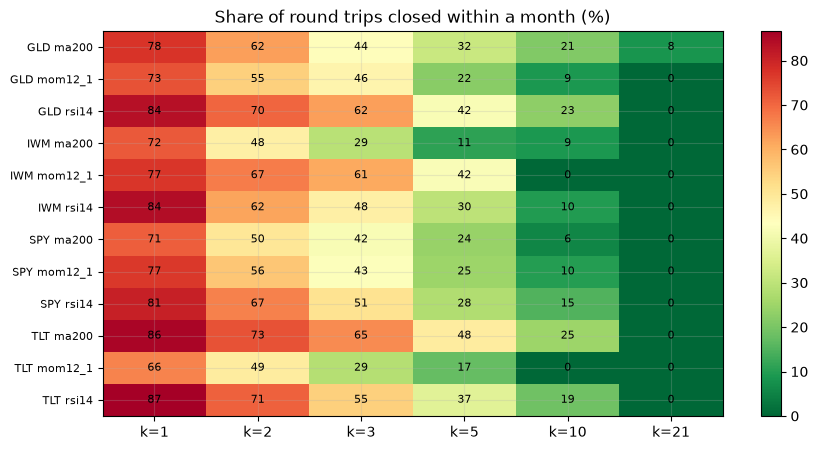

k
1    0.0000
2    1.0000
3    1.0000
5    1.0000
10   1.0000
21   1.0000


In [4]:
grid = st.full_grid(px, cash, data.RISKY, cost_bps=2.0)
ws = grid.pivot_table(index=["ticker", "signal"], columns="k", values="ws_whipsaw_share")
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(ws.values * 100, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(ws.shape[1])); ax.set_xticklabels([f"k={k}" for k in ws.columns])
ax.set_yticks(range(ws.shape[0]))
ax.set_yticklabels([f"{a} {b}" for a, b in ws.index], fontsize=8)
for i in range(ws.shape[0]):
    for j in range(ws.shape[1]):
        ax.text(j, i, f"{ws.values[i, j] * 100:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("Share of round trips closed within a month (%)")
fig.colorbar(im, ax=ax)
plt.show()
print((ws.diff(axis=1) <= 1e-12).mean().round(3).to_string())

### 3.2 The price, in basis points

ticker  signal  days_waiting  days_late_to_exit  delay_cost_bps  late_exit_cost_bps  share_disagreeing
   SPY   ma200           182                202     11,860.7040        -17,129.6900             0.0470
   SPY mom12_1           105                 95       -429.4160           -430.8740             0.0250
   SPY   rsi14           674                873     48,922.5080        -62,092.0740             0.1840
   IWM   ma200           159                217     14,036.4760        -19,501.5190             0.0590
   IWM mom12_1           164                167      1,257.7700             38.7790             0.0520
   IWM   rsi14           595                687     56,370.3880        -62,398.5700             0.1960
   TLT   ma200           229                210     11,388.8930        -10,514.2780             0.0750
   TLT mom12_1           125                139       -649.1730             -1.7110             0.0460
   TLT   rsi14           624                602     31,382.5320        -3

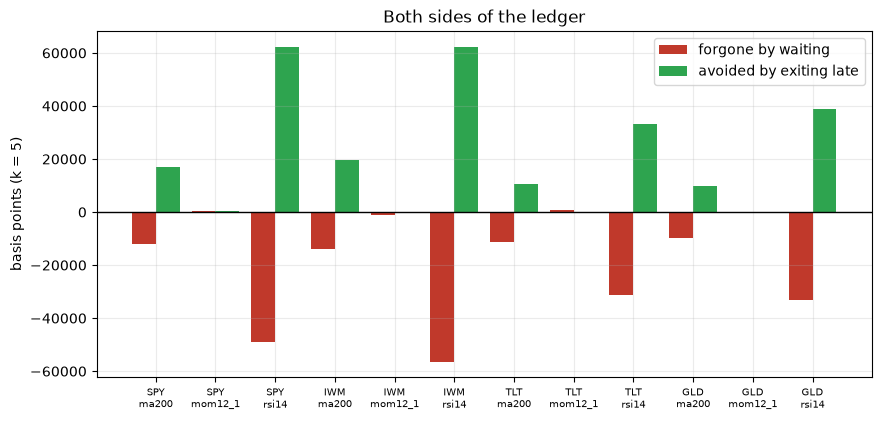

In [5]:
d = grid[grid["k"] == 5][["ticker", "signal", "days_waiting", "days_late_to_exit",
                          "delay_cost_bps", "late_exit_cost_bps", "share_disagreeing"]]
print(d.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(d))
ax.bar(x - 0.2, -d["delay_cost_bps"], width=0.4, color="#c0392b", label="forgone by waiting")
ax.bar(x + 0.2, -d["late_exit_cost_bps"], width=0.4, color="#2ea44f",
       label="avoided by exiting late")
ax.set_xticks(x); ax.set_xticklabels([f"{a}\n{b}" for a, b in zip(d['ticker'], d['signal'])],
                                     fontsize=7)
ax.axhline(0, color="k", lw=1); ax.set_ylabel("basis points (k = 5)")
ax.legend(); ax.set_title("Both sides of the ledger")
plt.show()

> \U0001F4A1 **In plain words.** A rule that waits misses the start of every rally *and*
> dodges the start of every fall. On a tape that mostly goes up, the first effect is bigger —
> which is why confirmation tends to help most on the assets that trend least.

### 3.3 Sharpe across the whole grid

k                  1      2      3      5      10     21
ticker signal                                           
GLD    ma200   0.6080 0.5900 0.6660 0.5970 0.5980 0.5710
       mom12_1 0.5880 0.5670 0.5970 0.6420 0.6340 0.6360
       rsi14   0.5230 0.5760 0.5600 0.5910 0.5650 0.6290
IWM    ma200   0.4310 0.4130 0.4920 0.5300 0.4210 0.2990
       mom12_1 0.3970 0.4540 0.4710 0.3780 0.3460 0.4300
       rsi14   0.2420 0.2340 0.4110 0.4710 0.4660 0.2870
SPY    ma200   0.7480 0.7790 0.7560 0.7950 0.7620 0.7930
       mom12_1 0.7720 0.7880 0.7880 0.7400 0.7370 0.7970
       rsi14   0.4520 0.4590 0.5420 0.5670 0.6850 0.7100
TLT    ma200   0.1050 0.2300 0.2410 0.2860 0.2630 0.1890
       mom12_1 0.2890 0.2700 0.2790 0.2660 0.2630 0.2750
       rsi14   0.2260 0.2200 0.2990 0.4190 0.3950 0.3390


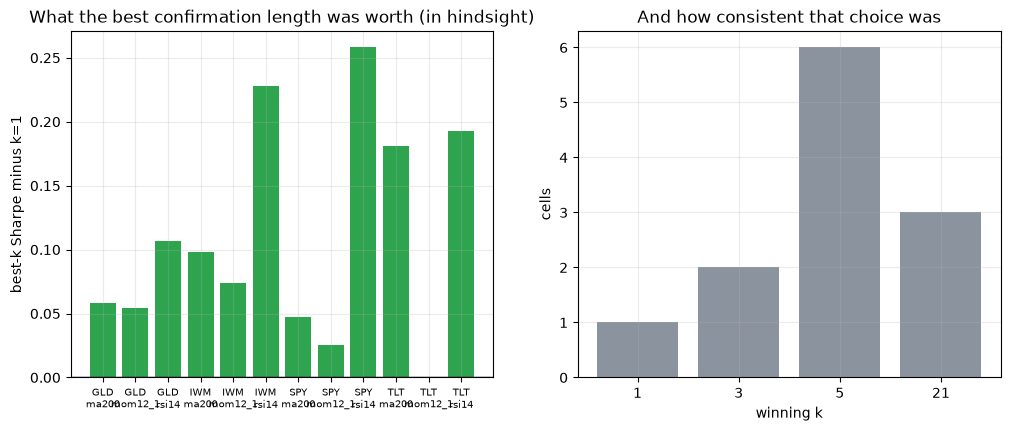

In [6]:
sh = grid.pivot_table(index=["ticker", "signal"], columns="k", values="sharpe")
print(sh.round(3).to_string())
best = st.best_k(grid)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(range(len(best)), best["gain"], color=["#2ea44f" if g > 0 else "#c0392b"
                                                   for g in best["gain"]])
axes[0].set_xticks(range(len(best)))
axes[0].set_xticklabels([f"{r.ticker}\n{r.signal}" for r in best.itertuples()], fontsize=7)
axes[0].axhline(0, color="k", lw=1); axes[0].set_ylabel("best-k Sharpe minus k=1")
axes[0].set_title("What the best confirmation length was worth (in hindsight)")
counts = best["best_k"].value_counts().sort_index()
axes[1].bar(counts.index.astype(str), counts.values, color="#8b949e")
axes[1].set_xlabel("winning k"); axes[1].set_ylabel("cells")
axes[1].set_title("And how consistent that choice was")
plt.show()

### 3.4 Against buy-and-hold — the context that decides whether any of this matters

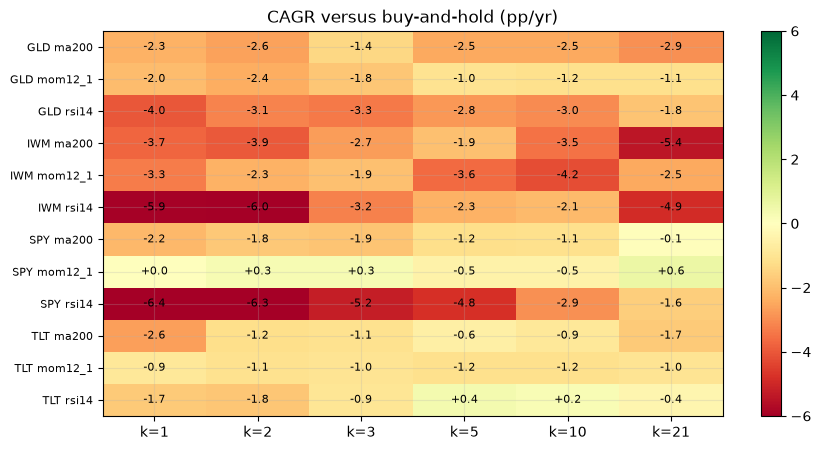

cells beating buy-and-hold: 8%


In [7]:
vs = grid.pivot_table(index=["ticker", "signal"], columns="k", values="cagr_vs_hold")
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(vs.values * 100, cmap="RdYlGn", vmin=-6, vmax=6, aspect="auto")
ax.set_xticks(range(vs.shape[1])); ax.set_xticklabels([f"k={k}" for k in vs.columns])
ax.set_yticks(range(vs.shape[0]))
ax.set_yticklabels([f"{a} {b}" for a, b in vs.index], fontsize=8)
for i in range(vs.shape[0]):
    for j in range(vs.shape[1]):
        ax.text(j, i, f"{vs.values[i, j] * 100:+.1f}", ha="center", va="center", fontsize=8)
ax.set_title("CAGR versus buy-and-hold (pp/yr)")
fig.colorbar(im, ax=ax)
plt.show()
print(f"cells beating buy-and-hold: {(vs > 0).to_numpy().mean():.0%}")

### 3.5 Could you have chosen k?

In [8]:
rows = []
for tk in data.RISKY:
    s_px = px[tk].dropna()
    mid = s_px.index[len(s_px) // 2]
    for sig in st.SIGNALS:
        first = st.sweep(s_px.loc[:mid], cash, sig, cost_bps=2.0)
        second = st.sweep(s_px.loc[mid:], cash, sig, cost_bps=2.0)
        k_pick = int(first["sharpe"].idxmax())
        rows.append({"ticker": tk, "signal": sig, "k chosen": k_pick,
                     "second-half Sharpe": second.loc[k_pick, "sharpe"],
                     "second-half k=1": second.loc[1, "sharpe"],
                     "gain": second.loc[k_pick, "sharpe"] - second.loc[1, "sharpe"],
                     "best k in hindsight": int(second["sharpe"].idxmax())})
oos = pd.DataFrame(rows)
print(oos.round(3).to_string(index=False))
print(f"\nchosen k beat k=1 on the second half in {(oos['gain'] > 0).mean():.0%} of cells; "
      f"mean gain {oos['gain'].mean():+.3f}")
print(f"the chosen k was also the hindsight winner "
      f"{(oos['k chosen'] == oos['best k in hindsight']).mean():.0%} of the time")

ticker  signal  k chosen  second-half Sharpe  second-half k=1    gain  best k in hindsight
   SPY   ma200        21              0.7380           0.9380 -0.2000                    1
   SPY mom12_1        21              0.7720           0.7750 -0.0040                    3
   SPY   rsi14        21              0.6140           0.6540 -0.0400                    3
   IWM   ma200         5              0.5890           0.4740  0.1150                    5
   IWM mom12_1         3              0.2340           0.1890  0.0440                   21
   IWM   rsi14         5              0.3740           0.2650  0.1080                    3
   TLT   ma200         3             -0.0110          -0.1910  0.1800                    5
   TLT mom12_1        10              0.0120           0.1670 -0.1550                    1
   TLT   rsi14        10              0.2210           0.1300  0.0910                    5
   GLD   ma200         3              0.6630           0.6660 -0.0030                    1

### 3.6 Cost sensitivity — the one thing that reliably changes the answer

          mean best k  mean Sharpe gain  share where waiting wins
cost_bps                                                         
0.0000        13.0000            0.1570                    1.0000
2.0000        13.0000            0.1960                    1.0000
10.0000       15.5000            0.3570                    1.0000
25.0000       15.5000            0.6700                    1.0000


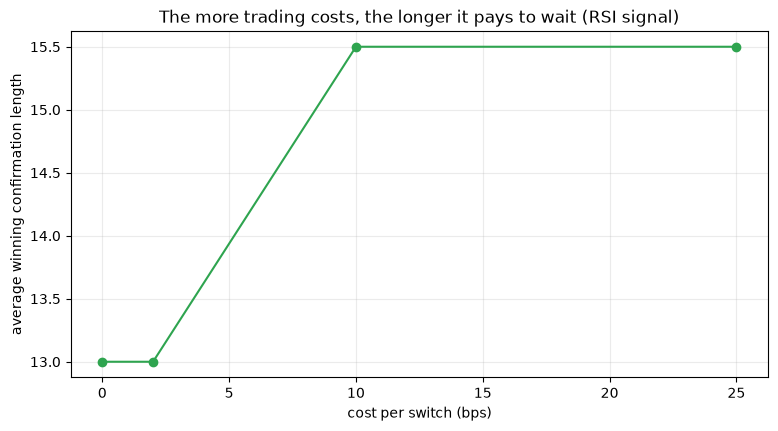

In [9]:
rows = []
for cost in (0.0, 2.0, 10.0, 25.0):
    g = st.full_grid(px, cash, data.RISKY, signals=("rsi14",), cost_bps=cost)
    b = st.best_k(g)
    rows.append({"cost_bps": cost, "mean best k": b["best_k"].mean(),
                 "mean Sharpe gain": b["gain"].mean(),
                 "share where waiting wins": (b["gain"] > 0).mean()})
d = pd.DataFrame(rows).set_index("cost_bps")
print(d.round(3).to_string())
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(d.index, d["mean best k"], marker="o", color="#2ea44f")
ax.set_xlabel("cost per switch (bps)"); ax.set_ylabel("average winning confirmation length")
ax.set_title("The more trading costs, the longer it pays to wait (RSI signal)")
plt.show()

### 3.7 The synthetic controls

      world  signal  whipsaw k=1  whipsaw k=5  best Sharpe gain  best k
   trending   ma200       0.8120       0.4740            0.0000       1
   trending mom12_1       0.7690       0.3570            0.0000       1
   trending   rsi14       0.8630       0.4580            0.0000       1
random walk   ma200       0.8220       0.3730            0.0360       2
random walk mom12_1       0.7750       0.3570            0.0090       5
random walk   rsi14       0.8690       0.4430            0.1440       5
     choppy   ma200       0.8260       0.2710            0.1140       2
     choppy mom12_1       0.7720       0.3930            0.0020      21
     choppy   rsi14       0.8770       0.4250            0.3250       5


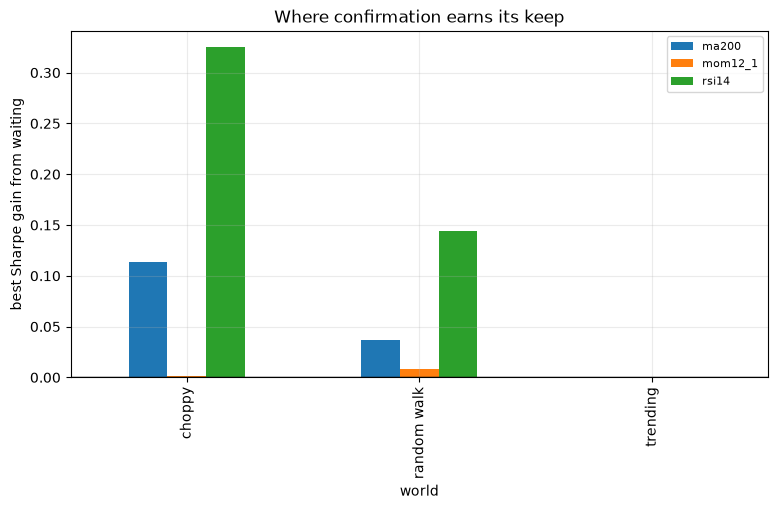

In [10]:
rows = []
for trend, tag in ((1.0, "trending"), (0.0, "random walk"), (-1.0, "choppy")):
    sim = st.synthetic_tape(n=8000, trendiness=trend, seed=981)
    for sig in st.SIGNALS:
        s_ = st.sweep(sim["ASSET"], sim["CASH"], sig, cost_bps=2.0)
        rows.append({"world": tag, "signal": sig,
                     "whipsaw k=1": s_.loc[1, "ws_whipsaw_share"],
                     "whipsaw k=5": s_.loc[5, "ws_whipsaw_share"],
                     "best Sharpe gain": s_["sharpe"].max() - s_.loc[1, "sharpe"],
                     "best k": int(s_["sharpe"].idxmax())})
d = pd.DataFrame(rows)
print(d.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 4.5))
d.pivot(index="world", columns="signal", values="best Sharpe gain").plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1); ax.set_ylabel("best Sharpe gain from waiting")
ax.legend(title="", fontsize=8)
ax.set_title("Where confirmation earns its keep")
plt.show()

## 4 · The verdict

In [11]:
summary = pd.DataFrame({
    "mean whipsaw share, k=1": [ws[1].mean()],
    "mean whipsaw share, k=5": [ws[5].mean()],
    "cells where some k beats k=1": [(best["gain"] > 0).mean()],
    "mean Sharpe gain (hindsight)": [best["gain"].mean()],
    "distinct winning k": [best["best_k"].nunique()],
    "out-of-sample win rate": [(oos["gain"] > 0).mean()],
    "cells beating buy-and-hold": [(vs > 0).to_numpy().mean()],
}).T.rename(columns={0: "value"})
summary.round(3)

,value
"mean whipsaw share, k=1",0.7780
"mean whipsaw share, k=5",0.2990
cells where some k beats k=1,0.9170
mean Sharpe gain (hindsight),0.1100
distinct winning k,4.0000
out-of-sample win rate,0.5830
cells beating buy-and-hold,0.0830


## 5 · Going further

- **Asymmetric confirmation**: wait on entries, act immediately on exits (or the reverse).
  Whipsaw is a round-trip phenomenon, so delaying one leg captures much of the benefit at half
  the cost.
- **Price bands** rather than time delays (Brock, Lakonishok & LeBaron's 1% filter).
- **Cost-aware selection**: section 3.6 suggests the right `k` is largely a function of the
  spread, which would make it choosable in advance after all — the one route to rescuing H₃.